# Plots cell track statistics from OBS and 3 LASSO resolutions for evaluation
## Cell tracks are run with regridding all data to 2.5 km at 15 min
### Config files:
- /tracking/config_csapr2.5km_template.yml
- /tracking/config_lasso_wrf2.5km_15min_template.yml
- /tracking/config_lasso_wrf500m_15min_regrid2.5km_template.yml
- /tracking/config_lasso_wrf100m_15min_regrid2.5km_template.yml
## Plots include:
- CI location frequency map (with SDC terrain overlaid)
- Cell lifetime-max diameter vs. ETH Joint KDE
- Cell lifetime PDF

In [43]:
import os, fnmatch
import glob
import datetime, calendar
from pytz import utc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import pandas as pd
import datetime
import copy
import seaborn as sns
from sklearn.neighbors import KernelDensity
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib import gridspec
import colorcet as cc

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [102]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/obs_lasso_evaluation_regrid2.5km/'
os.makedirs(figdir, exist_ok=True)

# CSAPR data directory
# dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/'
# dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/'
dir_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
dir_pixel_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_gridded.c1/'
# dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/celltracking/'
# dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqcM1_gridded_convmask.c1/'
terrain_file = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
radar_lat = -32.1264
radar_lon = -64.7284
# Start/end hours for OBS
# shour_obs = '09'
# ehour_obs = '03'
shour_obs = '12'
ehour_obs = '00'

# basename_obs = 'csapr_trackstats_'
basename_obs = 'trackstats_'
basename_obs25 = 'trackstats_'
# sat_basename = 'stats_goes16_'

# statsfiles_obs = []
statsfiles_obs25 = []
# satfiles_obs = []
satfiles_obs25 = []
for idate in start_dates:
    # statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))
    statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs25}{idate}*nc')))
    # satfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{sat_basename}{idate}*nc')))
    # satfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{sat_basename}{idate}*nc')))

# print(f'Number of cases (OBS): {len(statsfiles_obs)}')
print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
# print(f'Number of satellite files (OBS): {len(satfiles_obs)}')
# print(f'Number of satellite (OBS 2.5km): {len(satfiles_obs25)}')
# statsfiles_obs, statsfiles_obs25, satfiles_obs, satfiles_obs25
statsfiles_obs25

Number of cases (OBS 2.5km): 8


['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrp

In [12]:
# LASSO regridded cloud file basename for calculating total "scan" times
# cld_basename = 'corlasso.cldhamsl.'
cld_basename = 'corlasso_cldhamsl_'

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
# LASSO staged data directory
lassodir = '/gpfs/wolf2/arm/cli120/world-shared/d3m088/cacti/staged_runs/'
in_basename = 'trackstats_20'
# in_basename_tb = 'stats_tb_'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
lon_range = [-64.9, -63.3]
lat_range = [-33., -30.8]
lifetime_range = [30, 1000]  # [min]

# Find LASSO files
statsfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2_15min')
statsfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3_15min_2.5km')
statsfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min_2.5km')
# satfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_tb, 'd2_15min')
# satfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_tb, 'd3_15min')
# satfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_tb, 'd4_15min')

print(f'Number of stats files (D2): {len(statsfiles_d2)}')
print(f'Number of stats files (D3): {len(statsfiles_d3)}')
print(f'Number of stats files (D4): {len(statsfiles_d4)}')
# print(f'Number of tb files (D2): {len(satfiles_d2)}')
# print(f'Number of tb files (D3): {len(satfiles_d3)}')
# print(f'Number of tb files (D4): {len(satfiles_d4)}')
statsfiles_d2, statsfiles_d3, statsfiles_d4

Number of stats files (D2): 17
Number of stats files (D3): 17
Number of stats files (D4): 17


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2_15min/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfe

## Functions to count radar scan times

In [38]:
def get_obs_filetimes(
    data_path,
    data_basename,
    time_format="yyyymodd_hhmm",
):
    """
    Calculate base time (Epoch time) from filenames.

    Args:
        data_path: string
            Data directory name.
        data_basename: string
            Data base name.
        time_format: string (optional, default="yyyymodd_hhmm")
            Specify file time format to extract date/time.
    Returns:
        data_filenames: list
            List of data filenames.
        files_basetime: numpy array
            Array of file base time.
        files_datestring: list
            List of file date string.
        files_timestring: list
            List of file time string.

    """
    # logger = logging.getLogger(__name__)
    # Isolate all possible files
    filenames = sorted(fnmatch.filter(os.listdir(data_path), data_basename + '*'))

    # Loop through files, identifying files within the startdate - enddate interval
    nleadingchar = len(data_basename)

    data_filenames = [None]*len(filenames)
    files_timestring = [None]*len(filenames)
    files_datestring = [None]*len(filenames)
    files_basetime = np.full(len(filenames), -9999, dtype=int)
    files_datetime = []

    yyyy_idx = time_format.find("yyyy")
    mo_idx = time_format.find("mo")
    dd_idx = time_format.find("dd")
    hh_idx = time_format.find("hh")
    mm_idx = time_format.find("mm")
    ss_idx = time_format.find("ss")

    # Add basetime character counts to get the actual date/time string positions
    yyyy_idx = nleadingchar + yyyy_idx
    mo_idx = nleadingchar + mo_idx
    dd_idx = nleadingchar + dd_idx
    hh_idx = nleadingchar + hh_idx if (hh_idx != -1) else None
    mm_idx = nleadingchar + mm_idx if (mm_idx != -1) else None
    ss_idx = nleadingchar + ss_idx if (ss_idx != -1) else None

    # Loop over each file
    for ii, ifile in enumerate(filenames):
        year = ifile[yyyy_idx:yyyy_idx+4]
        month = ifile[mo_idx:mo_idx+2]
        day = ifile[dd_idx:dd_idx+2]
        # If hour, minute, second is not in time_format, assume 0
        hour = ifile[hh_idx:hh_idx+2] if (hh_idx is not None) else '00'
        minute = ifile[mm_idx:mm_idx+2] if (mm_idx is not None) else '00'
        second = ifile[ss_idx:ss_idx+2] if (ss_idx is not None) else '00'

        # Check month, day, hour, minute, second valid values
        if (0 <= int(month) <= 12) & (0 <= int(day) <= 31) & \
           (0 <= int(hour) <= 23) & (0 <= int(minute) <= 59) & (0 <= int(second) <= 59):
            TEMP_filetime = datetime.datetime(int(year), int(month), int(day),
                                            int(hour), int(minute), int(second), tzinfo=utc)
            files_basetime[ii] = calendar.timegm(TEMP_filetime.timetuple())
            TEMP_timestamp = pd.to_datetime(f'{year}{month}{day}.{hour}{minute}{second}', format='%Y%m%d.%H%M%S')
            files_datetime.append(TEMP_timestamp)
        else:
            print(f'File has invalid date/time, will not be included in processing: {ifile}')
            pass
        files_datestring[ii] = year + month + day
        files_timestring[ii] = hour + minute
        data_filenames[ii] = data_path + ifile
    files_datetime = np.array(files_datetime)
    return (
        # data_filenames,
        files_basetime,
        files_datetime,
        # files_datestring,
        # files_timestring,
    )

def count_times_obs(statsfiles, filetimes):
    """
    Count total times for observations
    
    Args:
        statsfiles: list
            List containing stats file names
        filetimes: list
            List containing all file times
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    # Loop over dates
    for ff in statsfiles:
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(ff)
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Count times within the track period
        _ntimes = np.count_nonzero((filetimes >= _sdate) & (filetimes <= _edate))
        # Add counts
        out_ntimes += _ntimes
        print(ff, _ntimes)

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

## Count total number of radar scan times from convective masks

In [45]:
# Get datetimes from OBS 2.5km pixel files
basename_obs25 = 'taranis_corcsapr2cfrppiqc2500mM1.c1.'
basetimes_obs25, filetimes_obs25 = get_obs_filetimes(dir_pixel_obs25, basename_obs25, time_format="yyyymodd_hhmmss")

# Count total scan times (OBS 2.5km)
ntimes_o25 = count_times_obs(statsfiles_obs25, filetimes_obs25)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc 48
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc 29
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500

## Functions to count LASSO file times (equivalent to radar scan times)

In [46]:
def count_times_lasso(statsfiles, frequency):
    """
    Count total times for all LASSO ensemble runs
    
    Args:
        statsfiles: list
            List containing stats file names
        frequency: string
            Frequency to generate time series
            
    Return:
        out_ntimes: int
            Total number of times
    """
    out_ntimes = 0
    for ff in range(len(statsfiles)):
        # Get start/end times from track stats attribute
        ds = xr.open_dataset(statsfiles[ff])
        _sdate = pd.to_datetime(ds.attrs['startdate'], format='%Y%m%d.%H%M')
        _edate = pd.to_datetime(ds.attrs['enddate'], format='%Y%m%d.%H%M')
        # Generate times within the track period based on input frequency
        _datetimes = pd.date_range(_sdate, _edate, freq=frequency)
        # Count times within the track period
        _ntimes = len(_datetimes)
        print(statsfiles[ff], _ntimes)
        # Add 
        out_ntimes += _ntimes

    print(f'Total ntimes: {out_ntimes}')
    return out_ntimes

## Count LASSO "scan" times

In [47]:
# Get LASSO file datetimes (d2)
freq_d2 = '15min'
ntimes_d2 = count_times_lasso(statsfiles_d2, freq_d2)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2_15min/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2_15min/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2_15min/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20

In [48]:
# Count d3 scan times
freq_d3 = '15min'
ntimes_d3 = count_times_lasso(statsfiles_d3, freq_d3)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base//d3_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base//d3_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base//d3_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base//d3_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base//d3_15min_2.5km/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base//d3_15min_2.5km/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181205/gefs01/base//d3_15min_2.5km/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm1

In [49]:
# Count d4 scan times
freq_d4 = '15min'
ntimes_d4 = count_times_lasso(statsfiles_d4, freq_d4)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/base//d4_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs18/base//d4_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/base//d4_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181129/gefs09/base//d4_15min_2.5km/stats/trackstats_20181129.1200_20181130.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/base//d4_15min_2.5km/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/base//d4_15min_2.5km/stats/trackstats_20181204.1200_20181205.0000.nc 49
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les//20181205/gefs01/base//d4_15min_2.5km/stats/trackstats_20181205.1200_20181206.0000.nc 49
/gpfs/wolf2/arm/atm1

## Read topography file

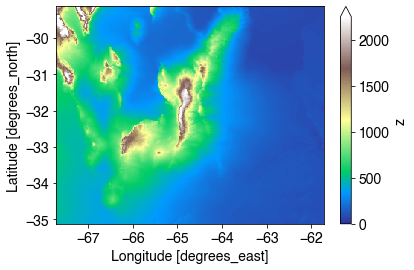

In [68]:
terr = xr.open_dataset(terrain_file)
topoZ = terr['z']
topoLon = terr['x']
topoLat = terr['y']
topoZ.plot(vmin=0, vmax=2250, cmap='terrain')

## Read track stats files

In [10]:
# Read track data (OBS 2.5km)
dst_o25 = xr.open_mfdataset(statsfiles_obs25, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_o25 = dst_o25.sizes['tracks']
dst_o25['tracks'] = np.arange(0, ntracks_o25)
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

# # Read satellite data
# dssat_o25 = xr.open_mfdataset(satfiles_obs25, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dssat_o25['tracks'] = np.arange(0, ntracks_o25)

# # Combine datasets by coordinates
# ds_o25 = xr.combine_by_coords([dst_o25, dssat_o25], combine_attrs='drop_conflicts')
# # ds_o25

ds_o25 = dst_o25
ds_o25

Number of tracks (OBS 2.5km): 486


<xarray.Dataset> Size: 4MB
Dimensions:                  (tracks: 486, times: 60)
Coordinates:
  * tracks                   (tracks) int64 4kB 0 1 2 3 4 ... 482 483 484 485
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/37)
    track_duration           (tracks) int32 2kB dask.array<chunksize=(55,), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 233kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlat                  (tracks, times) float32 117kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlon                  (tracks, times) float32 117kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area                     (tracks, times) float32 117kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloudnumber              (tracks, times) float64 233kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 4kB dask.array<chunksize=(55,), meta=np.ndarray>
Attributes:
    Title:                 Statistics of each track
    Institution:           Pacific Northwest National Laboratory
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    Created_on:            Tue Oct 11 13:56:38 2022
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [11]:
# Read track data (D2)
dst_d2 = xr.open_mfdataset(statsfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# # Read Tb data
# dssat_d2 = xr.open_mfdataset(satfiles_d2, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dssat_d2['tracks'] = np.arange(0, ntracks_d2)

# # Combine datasets by coordinates
# ds_d2 = xr.combine_by_coords([dst_d2, dssat_d2], combine_attrs='drop_conflicts')
# ds_d2

ds_d2 = dst_d2
ds_d2

Number of tracks (D2): 3923


<xarray.Dataset> Size: 30MB
Dimensions:                  (tracks: 3923, times: 60)
Coordinates:
  * tracks                   (tracks) int64 31kB 0 1 2 3 ... 3919 3920 3921 3922
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/37)
    track_duration           (tracks) int32 16kB dask.array<chunksize=(144,), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 2MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlat                  (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlon                  (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area                     (tracks, times) float32 942kB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloudnumber              (tracks, times) float64 2MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 31kB dask.array<chunksize=(144,), meta=np.ndarray>
Attributes:
    Title:                 Statistics of each track
    Institution:           Pacific Northwest National Laboratory
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    Created_on:            Wed Aug  2 20:00:39 2023
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [13]:
# Read track data (D3)
dst_d3 = xr.open_mfdataset(statsfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# # Read Tb data
# dssat_d3 = xr.open_mfdataset(satfiles_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dssat_d3['tracks'] = np.arange(0, ntracks_d3)

# # Combine datasets by coordinates
# ds_d3 = xr.combine_by_coords([dst_d3, dssat_d3], combine_attrs='drop_conflicts')
# ds_d3

ds_d3 = dst_d3
ds_d3

Number of tracks (D3): 5616


<xarray.Dataset> Size: 44MB
Dimensions:                  (tracks: 5616, times: 60)
Coordinates:
  * tracks                   (tracks) int64 45kB 0 1 2 3 ... 5612 5613 5614 5615
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/37)
    track_duration           (tracks) int32 22kB dask.array<chunksize=(194,), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 3MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlat                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlon                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area                     (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloudnumber              (tracks, times) float64 3MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 45kB dask.array<chunksize=(194,), meta=np.ndarray>
Attributes:
    Title:                 Statistics of each track
    Institution:           Pacific Northwest National Laboratory
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    Created_on:            Fri Jan  3 17:32:24 2025
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [14]:
# Read track data (D4)
dst_d4 = xr.open_mfdataset(statsfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# # Read Tb data
# dssat_d4 = xr.open_mfdataset(satfiles_d4, concat_dim='tracks', combine='nested')
# # Drop cell_area (because in the Tb file it is calculated at native 100m, where in the tracking it is calculated at 500m, the values are slightly different)
# # dropping this avoids conflict when combining the data
# dssat_d4 = dssat_d4.drop_vars('cell_area')
# # Renumber tracks to make it continuous
# dssat_d4['tracks'] = np.arange(0, ntracks_d4)

# # Combine datasets by coordinates
# ds_d4 = xr.combine_by_coords([dst_d4, dssat_d4], combine_attrs='drop_conflicts')
# ds_d4

ds_d4 = dst_d4
ds_d4

Number of tracks (D4): 4576


<xarray.Dataset> Size: 36MB
Dimensions:                  (tracks: 4576, times: 60)
Coordinates:
  * tracks                   (tracks) int64 37kB 0 1 2 3 ... 4572 4573 4574 4575
  * times                    (times) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
Data variables: (12/37)
    track_duration           (tracks) int32 18kB dask.array<chunksize=(157,), meta=np.ndarray>
    base_time                (tracks, times) datetime64[ns] 2MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlat                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    meanlon                  (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    area                     (tracks, times) float32 1MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    cloudnumber              (tracks, times) float64 2MB dask.array<chunksize=(1, 60), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 37kB dask.array<chunksize=(157,), meta=np.ndarray>
Attributes:
    Title:                 Statistics of each track
    Institution:           Pacific Northwest National Laboratory
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    Created_on:            Tue Dec 17 15:59:28 2024
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

## Subset tracks

In [15]:
def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    # start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) 
        # (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [17]:
time_res = 15.0  # [min]

ds_o25_s, track_idx = subset_tracks(ds_o25, time_res, lon_range, lat_range, lifetime_range)
ntracks_o25 = ds_o25_s.sizes['tracks']
print(f'Number of tracks (OBS 2.5km): {ntracks_o25}')

Number of tracks (OBS 2.5km): 211


In [18]:
ds_d2_s, track_idx = subset_tracks(ds_d2, time_res, lon_range, lat_range, lifetime_range)
ntracks_d2 = ds_d2_s.sizes['tracks']
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 1056


In [19]:
ds_d3_s, track_idx = subset_tracks(ds_d3, time_res, lon_range, lat_range, lifetime_range)
ntracks_d3 = ds_d3_s.sizes['tracks']
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 1139


In [20]:
ds_d4_s, track_idx = subset_tracks(ds_d4, time_res, lon_range, lat_range, lifetime_range)
ntracks_d4 = ds_d4_s.sizes['tracks']
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 1207


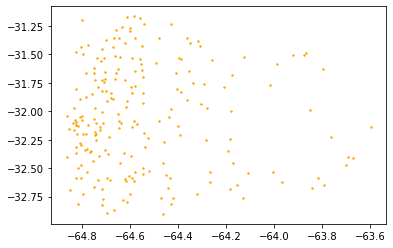

In [21]:
# plt.scatter(ds_o_s['meanlon'].mean(dim='times'), ds_o_s['meanlat'].mean(dim='times'), s=2, c='k')
plt.scatter(ds_o25_s['meanlon'].mean(dim='times'), ds_o25_s['meanlat'].mean(dim='times'), s=2, c='orange')

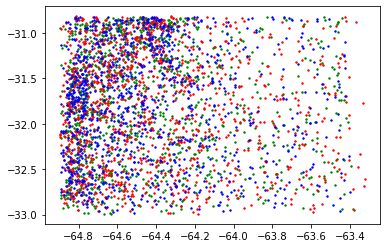

In [22]:
plt.scatter(ds_d3_s['meanlon'].mean(dim='times'), ds_d3_s['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4_s['meanlon'].mean(dim='times'), ds_d4_s['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2_s['meanlon'].mean(dim='times'), ds_d2_s['meanlat'].mean(dim='times'), s=2, c='b')

In [84]:
time_res_o25 = ds_o25.attrs['time_resolution_hour']
pixel_radius_o25 = ds_o25.attrs['pixel_radius_km']
lifetime_o25 = ds_o25['track_duration'] * time_res_o25

# Cell max reflectivity
maxdbz_o25 = ds_o25_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_o25 = ds_o25_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_o25 = ds_o25_s['cell_area'].load()
celldiam_o25 = 2 * np.sqrt(cellarea_o25 / np.pi)
# Cell min Tb
# minTb_o25 = ds_o25_s['temperature_ir_min'].load()

end_merge_tracknumber_o25 = ds_o25['end_merge_tracknumber'].load()
start_split_tracknumber_o25 = ds_o25['start_split_tracknumber'].load()
cell_lon_o25 = ds_o25['cell_meanlon'].load()
cell_lat_o25 = ds_o25['cell_meanlat'].load()

In [85]:
time_res_d2 = ds_d2.attrs['time_resolution_hour']
pixel_radius_d2 = ds_d2.attrs['pixel_radius_km']
lifetime_d2 = ds_d2['track_duration'] * time_res_d2

# Cell max reflectivity
maxdbz_d2 = ds_d2_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = ds_d2_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = ds_d2_s['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
# Cell min Tb
# minTb_d2 = ds_d2_s['temperature_ir_min'].load()

end_merge_tracknumber_d2 = ds_d2['end_merge_tracknumber']
start_split_tracknumber_d2 = ds_d2['start_split_tracknumber']
cell_lon_d2 = ds_d2['cell_meanlon']
cell_lat_d2 = ds_d2['cell_meanlat']

In [86]:
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3

# Cell max reflectivity
maxdbz_d3 = ds_d3_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d3 = ds_d3_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d3 = ds_d3_s['cell_area'].load()
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
# Cell min Tb
# minTb_d3 = ds_d3_s['temperature_ir_min'].load()

end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']

In [87]:
time_res_d4 = ds_d4.attrs['time_resolution_hour']
pixel_radius_d4 = ds_d4.attrs['pixel_radius_km']
lifetime_d4 = ds_d4['track_duration'] * time_res_d4

# Cell max reflectivity
maxdbz_d4 = ds_d4_s['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d4 = ds_d4_s['maxETH_10dbz'].load()
# Cell diameter
cellarea_d4 = ds_d4_s['cell_area'].load()
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Cell min Tb
# minTb_d4 = ds_d4_s['temperature_ir_min'].load()

end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']

In [28]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Function to plot MxN panel JointKDE

In [29]:
def jointKDE_MxN(nrow, ncol, data, margin_space=0.01, levels=None, cmap=None, lcolors=None, suptitle=None, fontsize=None,
                 titles=None, xlims=None, ylims=None, xlabels=None, ylabels=None, legend_loc='best', legend_labels=None, 
                 dpi=300, figsize=None, figname=None):
    
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize

    if figsize is None: figsize=(6 * ncol, 6 * nrow)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = gridspec.GridSpec(nrow, ncol, wspace=0.5, hspace=0.5)
    
    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    lw_joint = 2
    lw_fit = 5

    # Create a KDE plot with marginals for each cell in the grid
    for row in range(nrow):
        for col in range(ncol):
            # idx = i * ncol + j
            # x, y = data[idx]
            if (data[row][col] is not None):
                x_o, y_o = data[row][col]['o']
                x_m, y_m = data[row][col]['m']
                if (col==0): lc_m = lcolors['m1']
                if (col==1): lc_m = lcolors['m2']
                if (col==2): lc_m = lcolors['m3']
                # legend_lab = legend_labels[row][col]
                # legend_m = legend_labels[row][col]

                # Set up main axes for joint KDE plot in the GridSpec layout
                ax_joint = fig.add_subplot(gs[row, col])

                # Plot joint KDE
                sns.kdeplot(x=x_o, y=y_o, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=ax_joint)
                sns.kdeplot(x=x_m, y=y_m, color=lc_m, levels=levels, linewidths=lw_joint, fill=False, ax=ax_joint)
                ax_joint.set_xlabel(xlabels[row][col])
                ax_joint.set_ylabel(ylabels[row][col])
                ax_joint.grid(ls=':')
                
                # Linear regression (OBS)
                mask = ~np.isnan(x_o) & ~np.isnan(y_o)
                linfit = linregress(x=x_o[mask], y=y_o[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_o), np.nanmax(x_o), 100)
                yfit = linfit[0] * xfit + linfit[1]
                yfit_label = f"Corr: {linfit[2]:.02f}"
                ax_joint.plot(xfit, yfit, color=lcolors['o'], lw=lw_fit, label=yfit_label, zorder=5)

                # Linear regression (MODEL)
                mask = ~np.isnan(x_m) & ~np.isnan(y_m)
                linfit = linregress(x=x_m[mask], y=y_m[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_m), np.nanmax(x_m), 100)
                yfit = linfit[0] * xfit + linfit[1]
                yfit_label = f"Corr: {linfit[2]:.02f}"
                ax_joint.plot(xfit, yfit, color=lc_m, lw=lw_fit, label=yfit_label, zorder=5)
                
                # Create marginal axes with a small space between them and ax_joint
                pos = ax_joint.get_position()
                ax_marg_x = fig.add_axes([pos.x0, pos.y1 + margin_space, pos.width, 0.2 * pos.height])
                ax_marg_y = fig.add_axes([pos.x1 + margin_space, pos.y0, 0.2 * pos.width, pos.height])
                ax_marg_x.grid(axis='x', ls=':')
                ax_marg_y.grid(axis='y', ls=':')
                
                # Set x and y limits for ax_joint and apply to the marginal plots
                if xlims:
                    ax_joint.set_xlim(xlims[row][col])
                    ax_marg_x.set_xlim(xlims[row][col])
                if ylims:
                    ax_joint.set_ylim(ylims[row][col])
                    ax_marg_y.set_ylim(ylims[row][col])

                # Plot marginal KDEs on the marginal axes
                sns.kdeplot(x=x_o, ax=ax_marg_x, color=lcolors['o'], lw=lw_joint, fill=False)
                sns.kdeplot(y=y_o, ax=ax_marg_y, color=lcolors['o'], lw=lw_joint, fill=False)
                sns.kdeplot(x=x_m, ax=ax_marg_x, color=lc_m, lw=lw_joint, fill=False)
                sns.kdeplot(y=y_m, ax=ax_marg_y, color=lc_m, lw=lw_joint, fill=False)
                
                # # Adjust ylim of marginal plots to avoid cutting off the KDE line
                # y_lim_x = ax_marg_x.get_ylim()
                # ax_marg_x.set_ylim(y_lim_x[0] * 1.1, y_lim_x[1] * 1.1)  # Increase upper limit by 10%
                # y_lim_y = ax_marg_y.get_xlim()
                # ax_marg_y.set_xlim(y_lim_y[0] * 1.1, y_lim_y[1] * 1.1)  # Increase upper limit by 10%
                
                # Add title within the ax_joint at the upper left corner
                ax_joint.text(
                    0.02, 0.98,  # Position in axis coordinates
                    titles[row][col],
                    ha='left', va='top',
                    transform=ax_joint.transAxes,
                    # fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                )
                
                # Legends
                # ax_joint.legend(loc=legend_loc)
                legend_elements = [mpl.patches.Patch(facecolor=cmap(0.1), edgecolor='gray'),
                                   mpl.lines.Line2D([0], [0], color=lc_m, lw=lw_joint)]
                ax_joint.legend(handles=legend_elements, labels=legend_labels[row][col], 
                                loc=legend_loc, facecolor='w', 
                                # prop={'family':'Helvetica', 'size':18},
                               )

                # Remove tick labels and borders on the marginal plots
                ax_marg_x.set(yticks=[], ylabel=None)
                ax_marg_x.set_xticklabels([])  # Remove x-axis tick labels
                ax_marg_y.set(xticks=[], xlabel=None)
                ax_marg_y.set_yticklabels([])  # Remove y-axis tick labels
                ax_marg_x.tick_params(left=False, bottom=False)
                ax_marg_y.tick_params(left=False, bottom=False)
                # Show only the bottom spine (x-axis) for ax_marg_x and left spine (y-axis) for ax_marg_y
                ax_marg_x.spines['top'].set_visible(False)
                ax_marg_x.spines['right'].set_visible(False)
                ax_marg_x.spines['left'].set_visible(False)
                ax_marg_y.spines['top'].set_visible(False)
                ax_marg_y.spines['right'].set_visible(False)
                ax_marg_y.spines['bottom'].set_visible(False)
                # # Hide all spines
                # for spine in ax_marg_x.spines.values():
                #     spine.set_visible(False)
                # for spine in ax_marg_y.spines.values():
                #     spine.set_visible(False)

    if (suptitle): fig.suptitle(suptitle, weight='bold')
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

1 3


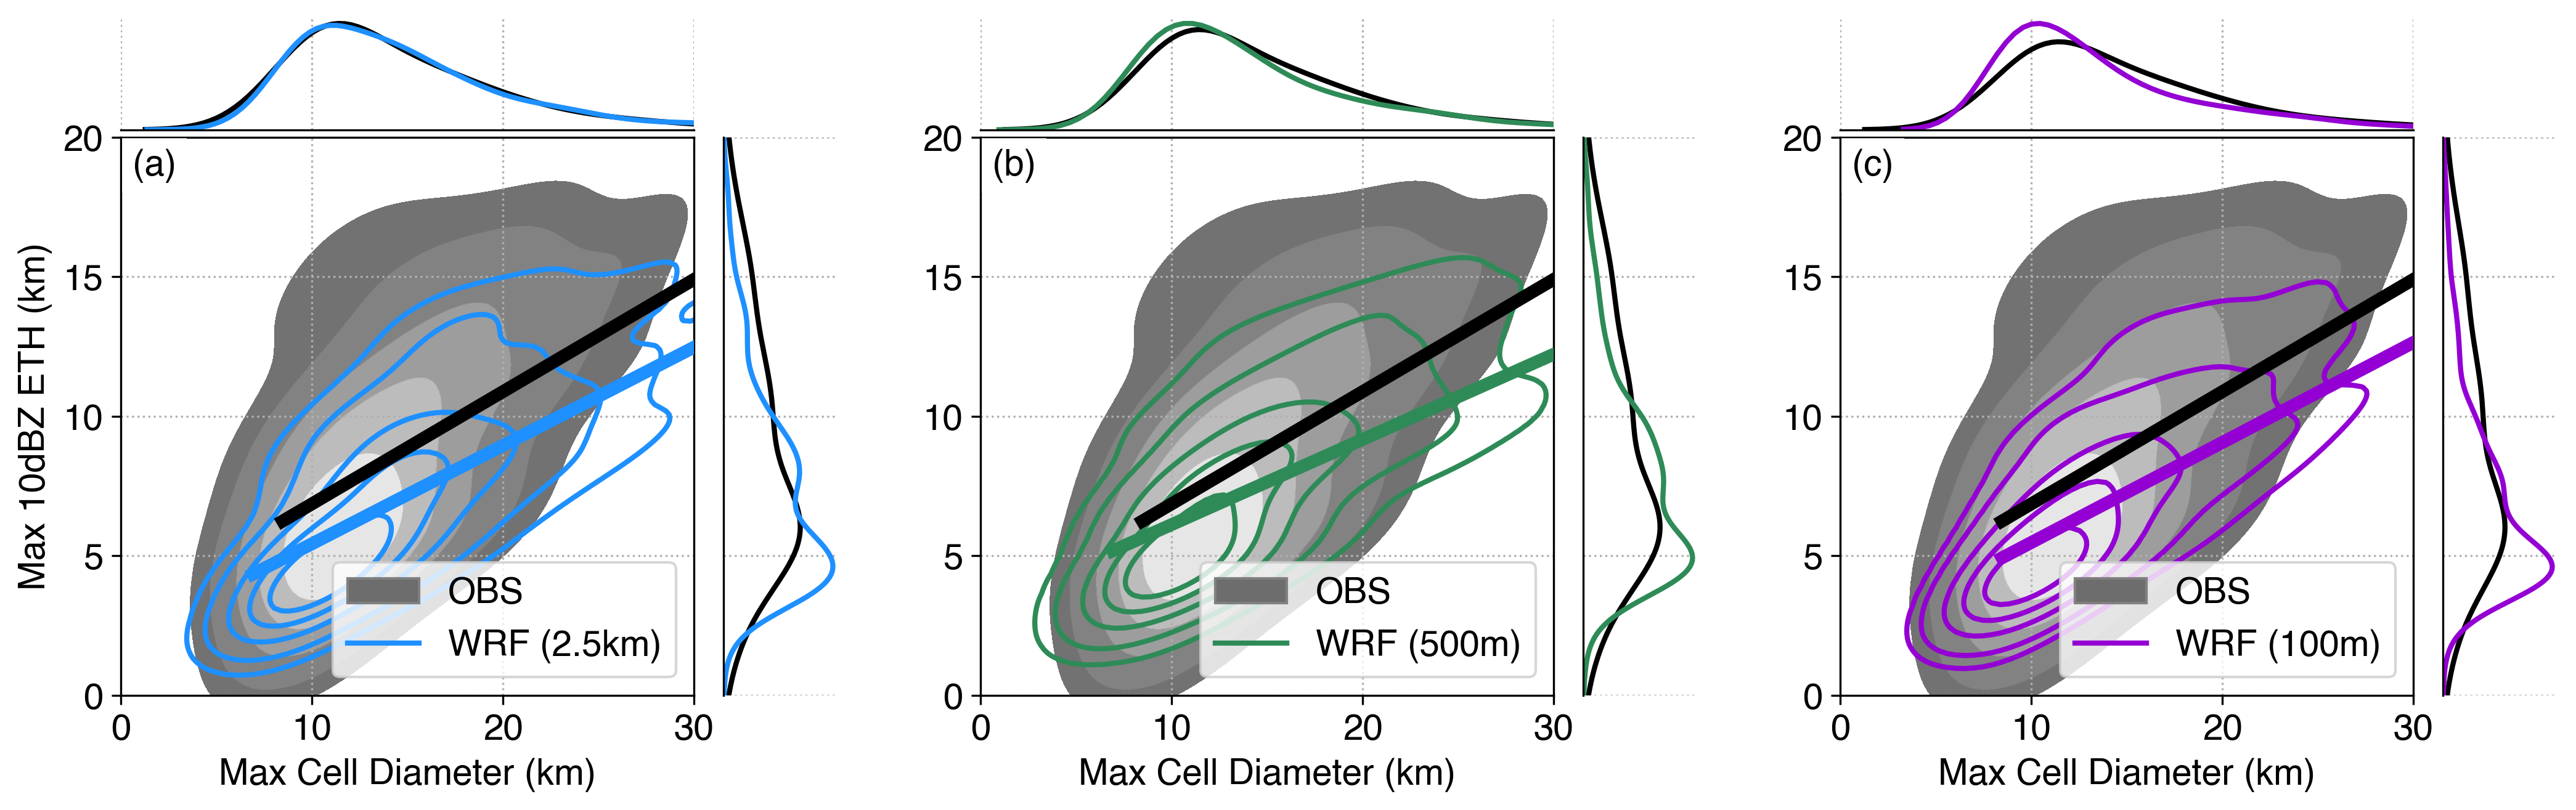

In [32]:
data_arr = [
    [{'o':[celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data], 
      'm':[celldiam_d2.max(dim='times').data, maxETH_10dbz_d2.max(dim='times').data]},
     {'o':[celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data], 
      'm':[celldiam_d3.max(dim='times').data, maxETH_10dbz_d3.max(dim='times').data]},
     {'o':[celldiam_o25.max(dim='times').data, maxETH_10dbz_o25.max(dim='times').data], 
      'm':[celldiam_d4.max(dim='times').data, maxETH_10dbz_d4.max(dim='times').data]},
    ],
]
nrow = len(data_arr)
ncol = len(data_arr[0])
print(nrow, ncol)

xlims = [[(0,30)]*ncol]
ylims = [[(0,20)]*ncol]

# cmap = 'YlGn'
cmap = cc.cm['CET_L1']
cmap = truncate_colormap(cmap, 0.4, 1)
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlabels = [['Max Cell Diameter (km)']*ncol]
ylabels = [['Max 10dBZ ETH (km)','','']]
titles = [['(a)', '(b)','(c)']]
lcolors = {'o':'k', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
# lcolors = {'o':'darkgreen', 'm1':'dodgerblue', 'm2':'seagreen', 'm3':'darkviolet'}
legend_labels = [
    [['OBS', 'WRF (2.5km)'],['OBS', 'WRF (500m)'],['OBS','WRF (100m)'],],
]
legend_loc = 'lower right'
fontsize = 14
figsize = (16,4)
# suptitle = 'Cell Max Diameter vs. Max ETH'
suptitle = None
margin_space = 0.01
figname = f'{figdir}JointKDE_MaxDiam_MaxETH10dBZ_obs_d2_d3_d4_regrid2.5km.png'
fig = jointKDE_MxN(nrow, ncol, data_arr, margin_space=margin_space, levels=levels, cmap=cmap, lcolors=lcolors, suptitle=suptitle, 
                   titles=titles, xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, legend_labels=legend_labels, legend_loc=legend_loc,
                   fontsize=fontsize, figsize=figsize, figname=figname,)

## Find merge/split tracks

In [34]:
# Find tracks not end with merge or not start with split
nonmerge_o25 = np.where(np.isnan(end_merge_tracknumber_o25))[0]
nonsplit_o25 = np.where(np.isnan(start_split_tracknumber_o25))[0]
ntracks_nonmerge_o25 = len(nonmerge_o25)
ntracks_nonsplit_o25 = len(nonsplit_o25)
print(f'Number of non-merge tracks (OBS 2.5km): {ntracks_nonmerge_o25}')
print(f'Number of non-split tracks (OBS 2.5km): {ntracks_nonsplit_o25}')

merge_o25 = np.where(end_merge_tracknumber_o25 > 0)[0]
split_o25 = np.where(start_split_tracknumber_o25 > 0)[0]
ntracks_merge_o25 = len(merge_o25)
ntracks_split_o25 = len(split_o25)
print(f'Number of merge tracks (OBS 2.5km): {ntracks_merge_o25}')
print(f'Number of split tracks (OBS 2.5km): {ntracks_split_o25}')

Number of non-merge tracks (OBS 2.5km): 331
Number of non-split tracks (OBS 2.5km): 303
Number of merge tracks (OBS 2.5km): 155
Number of split tracks (OBS 2.5km): 183


In [55]:
# Find tracks not end with merge or not start with split
nonmerge_d2 = np.where(np.isnan(end_merge_tracknumber_d2))[0]
nonsplit_d2 = np.where(np.isnan(start_split_tracknumber_d2))[0]
ntracks_nonmerge_d2 = len(nonmerge_d2)
ntracks_nonsplit_d2 = len(nonsplit_d2)
print(f'Number of non-merge tracks (d2): {ntracks_nonmerge_d2}')
print(f'Number of non-split tracks (d2): {ntracks_nonsplit_d2}')

merge_d2 = np.where(end_merge_tracknumber_d2 > 0)[0]
split_d2 = np.where(start_split_tracknumber_d2 > 0)[0]
ntracks_merge_d2 = len(merge_d2)
ntracks_split_d2 = len(split_d2)
print(f'Number of merge tracks (d2): {ntracks_merge_d2}')
print(f'Number of split tracks (d2): {ntracks_split_d2}')

Number of non-merge tracks (d2): 2161
Number of non-split tracks (d2): 2210
Number of merge tracks (d2): 1762
Number of split tracks (d2): 1713


In [56]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 2641
Number of non-split tracks (D3): 2681
Number of merge tracks (D3): 2975
Number of split tracks (D3): 2935


In [57]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 2462
Number of non-split tracks (D4): 2442
Number of merge tracks (D4): 2114
Number of split tracks (D4): 2134


## Get cell initiation locations

In [35]:
start_lon_o25 = cell_lon_o25.isel(times=0)
start_lat_o25 = cell_lat_o25.isel(times=0)
start_lon_nonsplit_o25 = cell_lon_o25.isel(tracks=nonsplit_o25, times=0)
start_lat_nonsplit_o25 = cell_lat_o25.isel(tracks=nonsplit_o25, times=0)

In [58]:
start_lon_d2 = cell_lon_d2.isel(times=0)
start_lat_d2 = cell_lat_d2.isel(times=0)
start_lon_nonsplit_d2 = cell_lon_d2.isel(tracks=nonsplit_d2, times=0)
start_lat_nonsplit_d2 = cell_lat_d2.isel(tracks=nonsplit_d2, times=0)

In [59]:
start_lon_d3 = cell_lon_d3.isel(times=0)
start_lat_d3 = cell_lat_d3.isel(times=0)
start_lon_nonsplit_d3 = cell_lon_d3.isel(tracks=nonsplit_d3, times=0)
start_lat_nonsplit_d3 = cell_lat_d3.isel(tracks=nonsplit_d3, times=0)

In [60]:
start_lon_d4 = cell_lon_d4.isel(times=0)
start_lat_d4 = cell_lat_d4.isel(times=0)
start_lon_nonsplit_d4 = cell_lon_d4.isel(tracks=nonsplit_d4, times=0)
start_lat_nonsplit_d4 = cell_lat_d4.isel(tracks=nonsplit_d4, times=0)

## Calculate spatial map of initiation locations

In [36]:
# Set domain boundary based on overlap area between OBS and D4
minlon, maxlon = -65.4, -63.5
minlat, maxlat = -33.1, -31.1
buffer = 0.05
# bins = [24, 24]
ranges = [[minlon+buffer,maxlon-buffer], [minlat+buffer,maxlat-buffer]]

lonbins = np.arange(minlon, maxlon, 0.1)
latbins = np.arange(minlat, maxlat, 0.1)
bins = [lonbins, latbins]

In [50]:
hist2d_startloc_o25, xbins, ybins = np.histogram2d(start_lon_o25.values, start_lat_o25.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o25, xbins, ybins = np.histogram2d(start_lon_nonsplit_o25.values, start_lat_nonsplit_o25.values, bins=bins, range=ranges)
hist2d_startloc_o25 = hist2d_startloc_o25.transpose()
hist2d_startloc_nonsplit_o25 = hist2d_startloc_nonsplit_o25.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_o25 = 100 * hist2d_startloc_o25 / ntimes_o25
freq2d_startloc_nonsplit_o25 = 100 * hist2d_startloc_nonsplit_o25 / ntimes_o25

In [61]:
hist2d_startloc_d2, xbins, ybins = np.histogram2d(start_lon_d2.values, start_lat_d2.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d2, xbins, ybins = np.histogram2d(start_lon_nonsplit_d2.values, start_lat_nonsplit_d2.values, bins=bins, range=ranges)
hist2d_startloc_d2 = hist2d_startloc_d2.transpose()
hist2d_startloc_nonsplit_d2 = hist2d_startloc_nonsplit_d2.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d2 = 100 * hist2d_startloc_d2 / ntimes_d2
freq2d_startloc_nonsplit_d2 = 100 * hist2d_startloc_nonsplit_d2 / ntimes_d2

In [62]:
hist2d_startloc_d3, xbins, ybins = np.histogram2d(start_lon_d3.values, start_lat_d3.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d3, xbins, ybins = np.histogram2d(start_lon_nonsplit_d3.values, start_lat_nonsplit_d3.values, bins=bins, range=ranges)
hist2d_startloc_d3 = hist2d_startloc_d3.transpose()
hist2d_startloc_nonsplit_d3 = hist2d_startloc_nonsplit_d3.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d3 = 100 * hist2d_startloc_d3 / ntimes_d3
freq2d_startloc_nonsplit_d3 = 100 * hist2d_startloc_nonsplit_d3 / ntimes_d3

In [63]:
hist2d_startloc_d4, xbins, ybins = np.histogram2d(start_lon_d4.values, start_lat_d4.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d4, xbins, ybins = np.histogram2d(start_lon_nonsplit_d4.values, start_lat_nonsplit_d4.values, bins=bins, range=ranges)
hist2d_startloc_d4 = hist2d_startloc_d4.transpose()
hist2d_startloc_nonsplit_d4 = hist2d_startloc_nonsplit_d4.transpose()

# Divide counts by total scan time to get frequency
freq2d_startloc_d4 = 100 * hist2d_startloc_d4 / ntimes_d4
freq2d_startloc_nonsplit_d4 = 100 * hist2d_startloc_nonsplit_d4 / ntimes_d4

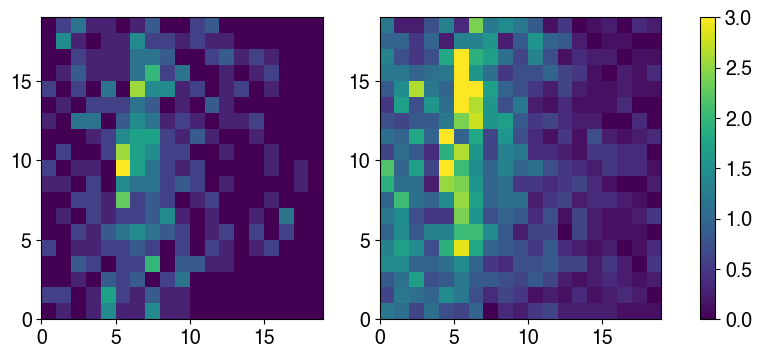

In [64]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
pcm = ax.pcolormesh(freq2d_startloc_o25, vmin=0, vmax=3.)
ax = axes[1]
pcm = ax.pcolormesh(freq2d_startloc_d2, vmin=0, vmax=3.)
fig.colorbar(pcm, ax=axes.ravel().tolist())

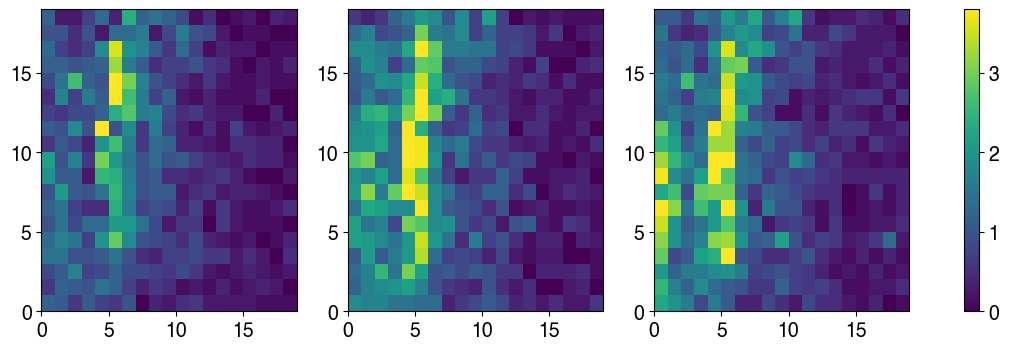

In [65]:
fig, axes = plt.subplots(1, 3, figsize=[14,4], dpi=100)
ax = axes[0]
pcm = ax.pcolormesh(freq2d_startloc_d2, vmin=0, vmax=3.8)
ax = axes[1]
pcm = ax.pcolormesh(freq2d_startloc_d3, vmin=0, vmax=3.8)
ax = axes[2]
pcm = ax.pcolormesh(freq2d_startloc_d4, vmin=0, vmax=3.8)
fig.colorbar(pcm, ax=axes.ravel().tolist())

In [73]:
def plot_Nheatmaps(ncol, dataarr, lonarr, latarr, topoZ, topoLon, topoLat, levels, cmaps, cmap_topo, cblabels, cbticks, titles, figname, 
                   eSDC=None, oob_colors=None, figsize=[15.5,5]):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(1, ncol, figsize=figsize, dpi=100)
    marker_style = dict(color='k', linestyle='none', marker='o', markersize=12, markerfacecolor='red')
    topo_levs = [500,1000,1500,2000,2500]

    for col in range(ncol):
        ax = axes[col]
        Zm = np.ma.masked_where(dataarr[col] == 0, dataarr[col])
        cmap = copy.copy(mpl.cm.get_cmap(cmaps))
        norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
        p1 = ax.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
        ax.set_xlabel('Longitude')
        if (col == 0): ax.set_ylabel('Latitude')
        ax.set_title(titles[col], loc='left')
        ax.set_xlim(np.min(lonarr), np.max(lonarr))
        ax.set_ylim(np.min(latarr), np.max(latarr))
        ax.set_xticks(np.arange(-65., maxlon, 0.5))
        ax.set_yticks(np.arange(-33, maxlat, 0.5))
        ax.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
        ax.plot(radar_lon, radar_lat, **marker_style)
        ax.grid(ls='--')
        if eSDC is not None:
            ax.axvline(x=eSDC, color='magenta', lw=2)
        # Legend for terrain
        if (col == 0):
            custom_lines = [mpl.lines.Line2D([0], [0], color=plt.get_cmap(cmap_topo)(0.8), lw=2)]
            ax.legend(custom_lines, ['Terrain'], loc='upper right')
        # Set out of bound colors
        if oob_colors is not None:
            p1.cmap.set_over(oob_colors['over'])
            p1.cmap.set_under(oob_colors['under'])
            p1.set_clim(min(levels), max(levels))
    
    fig.tight_layout()
    fig.colorbar(p1, ax=axes.ravel().tolist(), ticks=cbticks, pad=0.02, label=cblabels, extend='both')
    fig.savefig(figname, bbox_inches='tight', facecolor='w', dpi=300)
    
    return fig

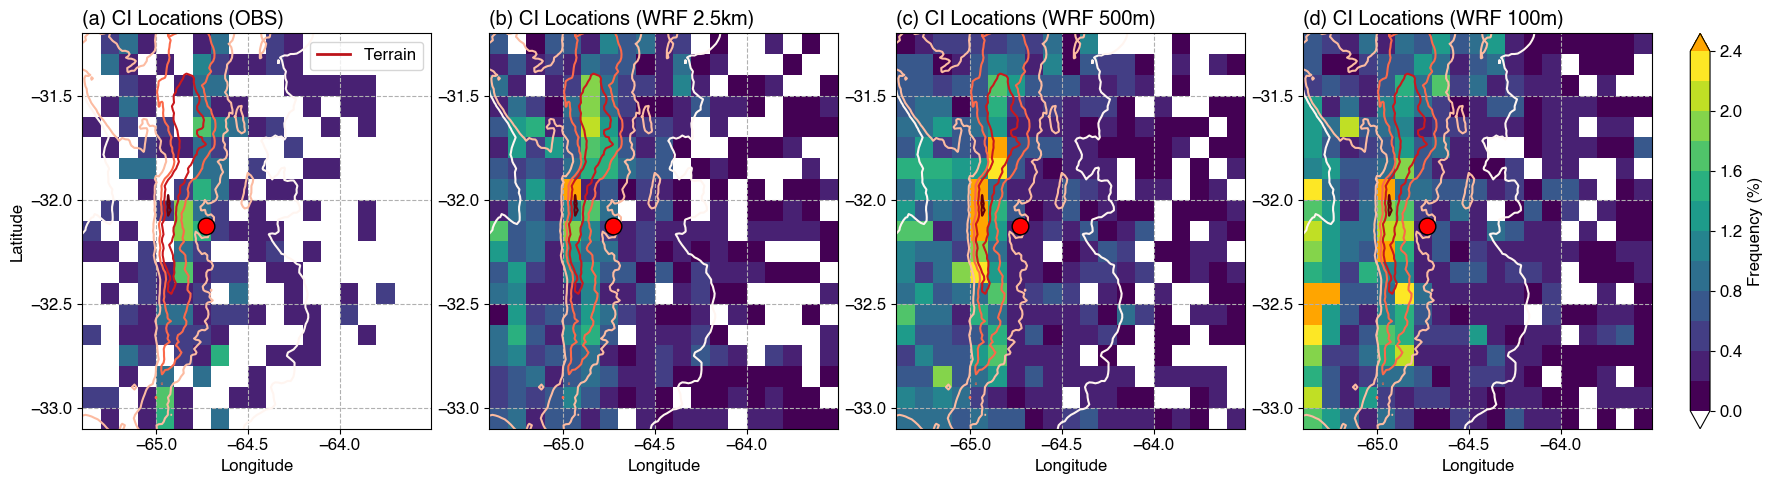

In [80]:
dataarr = [freq2d_startloc_nonsplit_o25, freq2d_startloc_nonsplit_d2, freq2d_startloc_nonsplit_d3, freq2d_startloc_nonsplit_d4]
ncol = len(dataarr)
levels = np.arange(0, 2.41, 0.2)
cbticks = np.arange(0, 2.41, 0.4)
# levels = np.arange(0, 2.1, 0.1)
# cbticks = np.arange(0, 2.1, 0.2)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) CI Locations (OBS)', '(b) CI Locations (WRF 2.5km)', '(c) CI Locations (WRF 500m)', '(d) CI Locations (WRF 100m)']
cblabels = 'Frequency (%)'
figsize = [20,5]
figname = f'{figdir}celltrack_start_loc_nonsplit_freq_0.1deg_obs_d2_d3_d4_regrid2.5km.png'
fig = plot_Nheatmaps(ncol, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

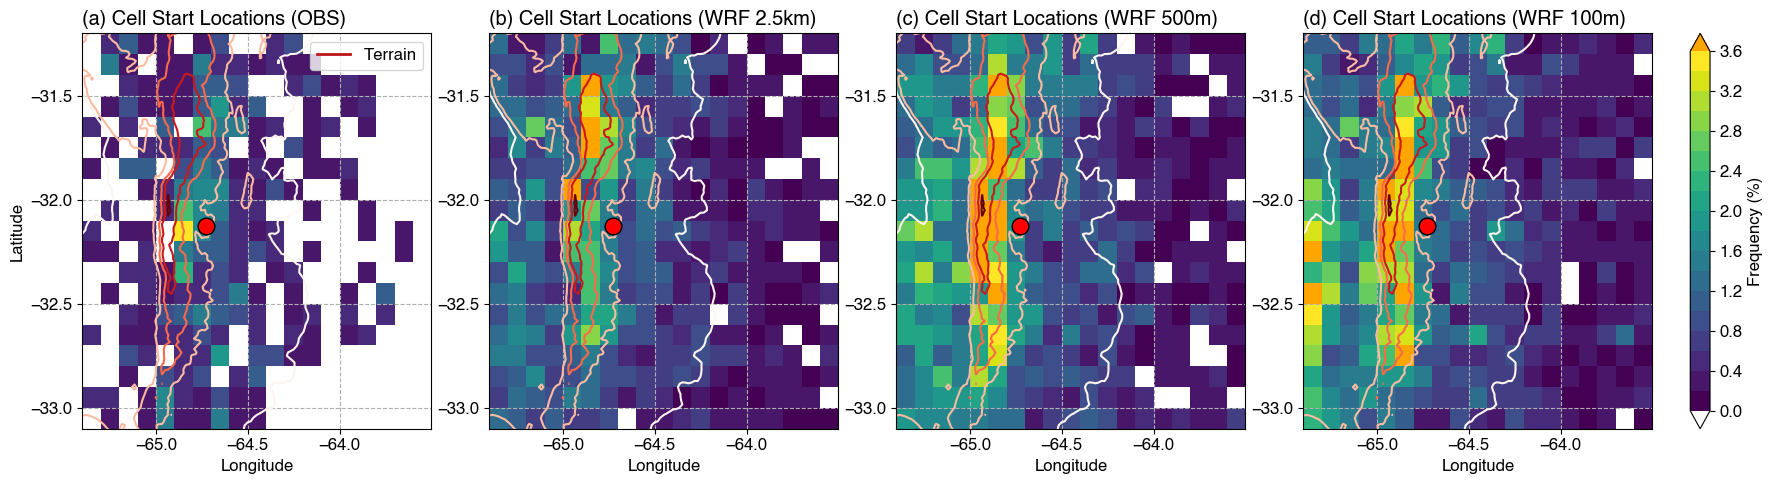

In [81]:
dataarr = [freq2d_startloc_o25, freq2d_startloc_d2, freq2d_startloc_d3, freq2d_startloc_d4]
ncol = len(dataarr)
levels = np.arange(0, 3.61, 0.2)
cbticks = np.arange(0, 3.61, 0.4)
# levels = np.arange(0, 2.1, 0.1)
# cbticks = np.arange(0, 2.1, 0.2)
cmap = 'viridis'
cmap_topo = 'Reds'
oob_colors = {'under':'white', 'over':'orange'}
titles = ['(a) Cell Start Locations (OBS)', '(b) Cell Start Locations (WRF 2.5km)', '(c) Cell Start Locations (WRF 500m)', '(d) Cell Start Locations (WRF 100m)']
cblabels = 'Frequency (%)'
figsize = [20,5]
figname = f'{figdir}celltrack_start_loc_freq_0.1deg_obs_d2_d3_d4_regrid2.5km.png'
fig = plot_Nheatmaps(ncol, dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, cbticks, titles, figname, oob_colors=oob_colors, figsize=figsize)

In [88]:
lifetime_nomerge_o25 = lifetime_o25.isel(tracks=nonmerge_o25, drop=True)
ncells_nomerge_o25 = lifetime_nomerge_o25.count().values
ncells_nomerge_gt30min_o25 = np.count_nonzero(lifetime_nomerge_o25 > 0.5)
ncells_nomerge_ge1hour_o25 = np.count_nonzero(lifetime_nomerge_o25 >= 1.0)
frac_nomerge_gt30min_o25 = 100 * ncells_nomerge_gt30min_o25 / ncells_nomerge_o25
frac_nomerge_ge1hour_o25 = 100 * ncells_nomerge_ge1hour_o25 / ncells_nomerge_o25
print(f'All non-merge cells (OBS 2.5km): {ncells_nomerge_o25}')
print(f'Non-merge cells (OBS 2.5km) > 30 min: {ncells_nomerge_gt30min_o25}')
print(f'Non-merge cells (OBS 2.5km) >= 1 hour: {ncells_nomerge_ge1hour_o25}')
print(f'Fraction of cells (OBS 2.5km) (> 30 min): {frac_nomerge_gt30min_o25}%')
print(f'Fraction of cells (OBS 2.5km) (>= 1 hour): {frac_nomerge_ge1hour_o25}%')

All non-merge cells (OBS 2.5km): 331
Non-merge cells (OBS 2.5km) > 30 min: 165
Non-merge cells (OBS 2.5km) >= 1 hour: 116
Fraction of cells (OBS 2.5km) (> 30 min): 49.848942598187314%
Fraction of cells (OBS 2.5km) (>= 1 hour): 35.04531722054381%


In [90]:
lifetime_nomerge_d2 = lifetime_d2.isel(tracks=nonmerge_d2, drop=True)
ncells_nomerge_d2 = lifetime_nomerge_d2.count().values
ncells_nomerge_gt30min_d2 = np.count_nonzero(lifetime_nomerge_d2 > 0.5)
ncells_nomerge_ge1hour_d2 = np.count_nonzero(lifetime_nomerge_d2 >= 1.0)
frac_nomerge_gt30min_d2 = 100 * ncells_nomerge_gt30min_d2 / ncells_nomerge_d2
frac_nomerge_ge1hour_d2 = 100 * ncells_nomerge_ge1hour_d2 / ncells_nomerge_d2
print(f'All non-merge cells (D2): {ncells_nomerge_d2}')
print(f'Non-merge cells (D2) > 30 min: {ncells_nomerge_gt30min_d2}')
print(f'Non-merge cells (D2) >= 1 hour: {ncells_nomerge_ge1hour_d2}')
print(f'Fraction of cells (D2) (> 30 min): {frac_nomerge_gt30min_d2}%')
print(f'Fraction of cells (D2) (>= 1 hour): {frac_nomerge_ge1hour_d2}%')

All non-merge cells (D2): 2161
Non-merge cells (D2) > 30 min: 1105
Non-merge cells (D2) >= 1 hour: 739
Fraction of cells (D2) (> 30 min): 51.13373438223045%
Fraction of cells (D2) (>= 1 hour): 34.19713095788987%


In [91]:
lifetime_nomerge_d3 = lifetime_d3.isel(tracks=nonmerge_d3, drop=True)
ncells_nomerge_d3 = lifetime_nomerge_d3.count().values
ncells_nomerge_gt30min_d3 = np.count_nonzero(lifetime_nomerge_d3 > 0.5)
ncells_nomerge_ge1hour_d3 = np.count_nonzero(lifetime_nomerge_d3 >= 1.0)
frac_nomerge_gt30min_d3 = 100 * ncells_nomerge_gt30min_d3 / ncells_nomerge_d3
frac_nomerge_ge1hour_d3 = 100 * ncells_nomerge_ge1hour_d3 / ncells_nomerge_d3
print(f'All non-merge cells (D3): {ncells_nomerge_d3}')
print(f'Non-merge cells (D3) > 30 min: {ncells_nomerge_gt30min_d3}')
print(f'Non-merge cells (D3) >= 1 hour: {ncells_nomerge_ge1hour_d3}')
print(f'Fraction of cells (D3) (> 30 min): {frac_nomerge_gt30min_d3}%')
print(f'Fraction of cells (D3) (>= 1 hour): {frac_nomerge_ge1hour_d3}%')

All non-merge cells (D3): 2641
Non-merge cells (D3) > 30 min: 1130
Non-merge cells (D3) >= 1 hour: 736
Fraction of cells (D3) (> 30 min): 42.78682317304052%
Fraction of cells (D3) (>= 1 hour): 27.86823173040515%


In [92]:
lifetime_nomerge_d4 = lifetime_d4.isel(tracks=nonmerge_d4, drop=True)
ncells_nomerge_d4 = lifetime_nomerge_d4.count().values
ncells_nomerge_gt30min_d4 = np.count_nonzero(lifetime_nomerge_d4 > 0.5)
ncells_nomerge_ge1hour_d4 = np.count_nonzero(lifetime_nomerge_d4 >= 1.0)
frac_nomerge_gt30min_d4 = 100 * ncells_nomerge_gt30min_d4 / ncells_nomerge_d4
frac_nomerge_ge1hour_d4 = 100 * ncells_nomerge_ge1hour_d4 / ncells_nomerge_d4
print(f'All non-merge cells (D4): {ncells_nomerge_d4}')
print(f'Non-merge cells (D4) > 30 min: {ncells_nomerge_gt30min_d4}')
print(f'Non-merge cells (D4) >= 1 hour: {ncells_nomerge_ge1hour_d4}')
print(f'Fraction of cells (D4) (> 30 min): {frac_nomerge_gt30min_d4}%')
print(f'Fraction of cells (D4) (>= 1 hour): {frac_nomerge_ge1hour_d4}%')

All non-merge cells (D4): 2462
Non-merge cells (D4) > 30 min: 1143
Non-merge cells (D4) >= 1 hour: 748
Fraction of cells (D4) (> 30 min): 46.425670186839966%
Fraction of cells (D4) (>= 1 hour): 30.381803411860275%


In [94]:
bins_lifetime = np.arange(21)*0.25
bins_lifetime_c = bins_lifetime[:-1] + np.diff(bins_lifetime)/2
# hist_lifetime_o, bins = np.histogram(lifetime_o, bins=bins_lifetime, range=(0,5), density=True)
# hist_lifetime_nonmerge_o, bins = np.histogram(lifetime_o.isel(tracks=nonmerge_o), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_o25, bins = np.histogram(lifetime_o25, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_o25, bins = np.histogram(lifetime_o25.isel(tracks=nonmerge_o25), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d2, bins = np.histogram(lifetime_d2, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d2, bins = np.histogram(lifetime_d2.isel(tracks=nonmerge_d2), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d3, bins = np.histogram(lifetime_d3, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d3, bins = np.histogram(lifetime_d3.isel(tracks=nonmerge_d3), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d4, bins = np.histogram(lifetime_d4, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d4, bins = np.histogram(lifetime_d4.isel(tracks=nonmerge_d4), bins=bins_lifetime, range=(0,5), density=True)

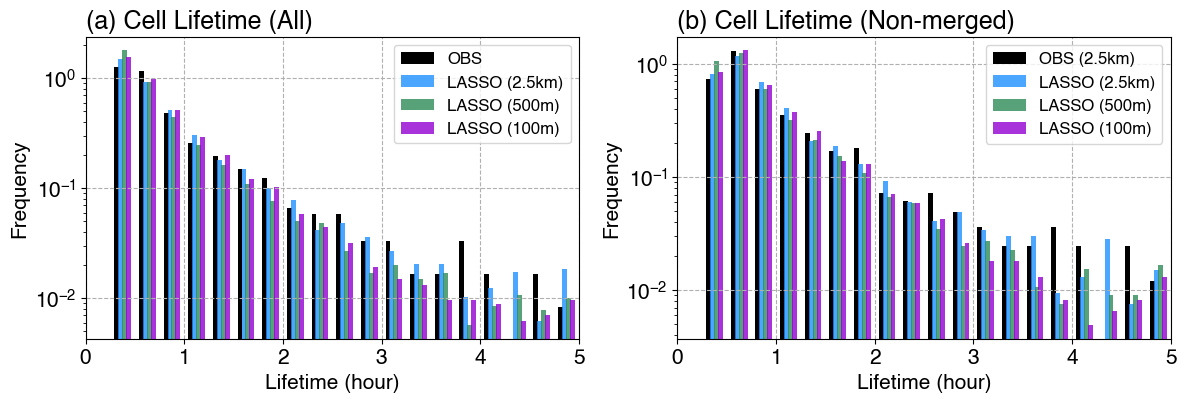

In [99]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

# colors = {'obs':'k', 'obs25':'gray', 'd2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
colors = {'obs25':'k', 'd2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
bwidth = 0.05

ax1 = axes[0]
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b0 = ax1.bar(bins_lifetime_c-0.06, hist_lifetime_o25, width=bwidth, color=colors['obs25'], label='OBS')
# b1 = ax1.bar(bins_lifetime_c-0.06, hist_lifetime_o, width=bwidth, color=colors['obs'], label='OBS (500m)')
b2 = ax1.bar(bins_lifetime_c-0.02, hist_lifetime_d2, width=bwidth, color=colors['d2'], alpha=0.8, label='LASSO (2.5km)')
b3 = ax1.bar(bins_lifetime_c+0.02, hist_lifetime_d3, width=bwidth, color=colors['d3'], alpha=0.8, label='LASSO (500m)')
b4 = ax1.bar(bins_lifetime_c+0.06, hist_lifetime_d4, width=bwidth, color=colors['d4'], alpha=0.8, label='LASSO (100m)')
ax1.legend(fontsize=12)
ax1.set_xlim(0, 5)
ax1.set_title('(a) Cell Lifetime (All)', loc='left')
ax1.grid(ls='--')
ax1.set_yscale('log')

ax2 = axes[1]
ax2.set_xlabel('Lifetime (hour)')
ax2.set_ylabel('Frequency')
b0 = ax2.bar(bins_lifetime_c-0.06, hist_lifetime_nonmerge_o25, width=bwidth, color=colors['obs25'], label='OBS (2.5km)')
# b1 = ax2.bar(bins_lifetime_c-0.06, hist_lifetime_nonmerge_o, width=bwidth, color=colors['obs'], label='OBS (500m)')
b2 = ax2.bar(bins_lifetime_c-0.02, hist_lifetime_nonmerge_d2, width=bwidth, color=colors['d2'], alpha=0.8, label='LASSO (2.5km)')
b3 = ax2.bar(bins_lifetime_c+0.02, hist_lifetime_nonmerge_d3, width=bwidth, color=colors['d3'], alpha=0.8, label='LASSO (500m)')
b4 = ax2.bar(bins_lifetime_c+0.06, hist_lifetime_nonmerge_d4, width=bwidth, color=colors['d4'], alpha=0.8, label='LASSO (100m)')
ax2.legend(fontsize=12)
ax2.set_xlim(0, 5)
ax2.set_title('(b) Cell Lifetime (Non-merged)', loc='left')
ax2.grid(ls='--')
ax2.set_yscale('log')
fig.savefig(f'{figdir}celltrack_lifetime_pdf_bars_obs_d2_d3_d4_regrid2.5km.png', bbox_inches='tight', dpi=300, facecolor='w')

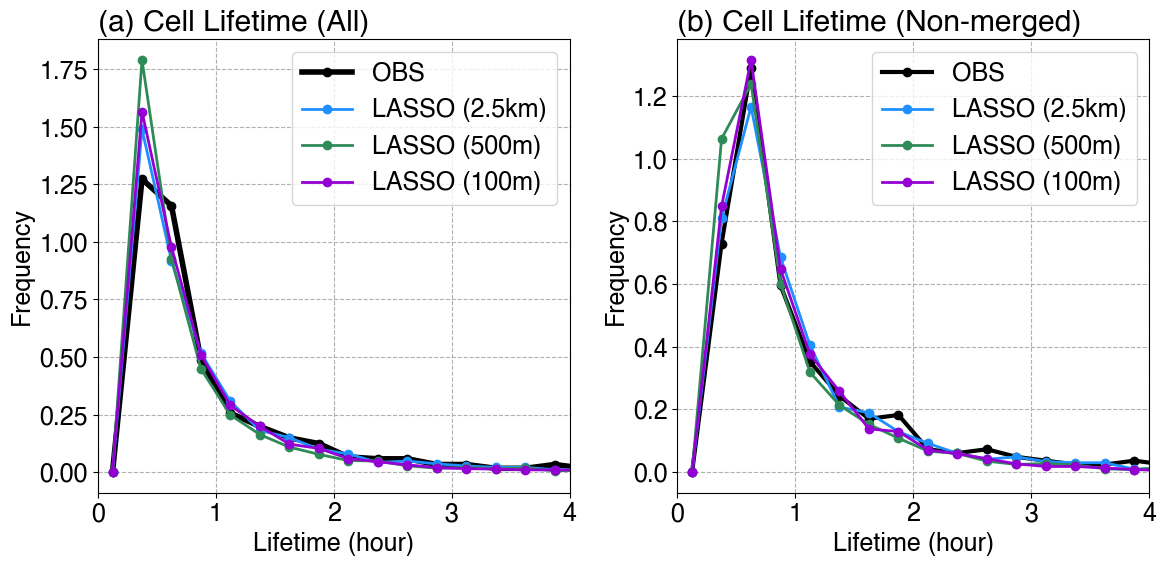

In [100]:
mpl.rcParams['font.size'] = 18
mpl.rcParams['font.family'] = 'Helvetica'
colors = {'obs25':'k', 'd2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
lw = 2
marker = 'o'
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

ax0 = axes[0]
ax0.set_xlabel('Lifetime (hour)')
ax0.set_ylabel('Frequency')
# b1 = ax0.plot(bins_lifetime_c, hist_lifetime_o, color=colors['obs'], marker=marker, lw=lw*2, label='OBS (500m)')
b0 = ax0.plot(bins_lifetime_c, hist_lifetime_o25, color=colors['obs25'], marker=marker, lw=lw*2, label='OBS')
b2 = ax0.plot(bins_lifetime_c, hist_lifetime_d2, color=colors['d2'], marker=marker, lw=lw, label='LASSO (2.5km)')
b3 = ax0.plot(bins_lifetime_c, hist_lifetime_d3, color=colors['d3'], marker=marker, lw=lw, label='LASSO (500m)')
b4 = ax0.plot(bins_lifetime_c, hist_lifetime_d4, color=colors['d4'], marker=marker, lw=lw, label='LASSO (100m)')
ax0.legend()
ax0.set_xlim(0, 4)
ax0.set_title('(a) Cell Lifetime (All)', loc='left')
ax0.grid(ls='--')

ax1 = axes[1]
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
# b1 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o, color=colors['obs'], marker=marker, lw=lw*1.5, label='OBS (500m)')
b0 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o25, color=colors['obs25'], marker=marker, lw=lw*1.5, label='OBS')
b2 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d2, color=colors['d2'], marker=marker, lw=lw, label='LASSO (2.5km)')
b3 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d3, color=colors['d3'], marker=marker, lw=lw, label='LASSO (500m)')
b4 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d4, color=colors['d4'], marker=marker, lw=lw, label='LASSO (100m)')
ax1.legend()
ax1.set_xlim(0, 4)
ax1.set_title('(b) Cell Lifetime (Non-merged)', loc='left')
ax1.grid(ls='--')

fig.tight_layout()
fig.savefig(f'{figdir}celltrack_lifetime_pdf_lines_obs_d2_d3_d4_regrid2.5km.png', bbox_inches='tight', dpi=300, facecolor='w')

In [101]:
figdir

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'